# Preparation for GMA of absolute n_TOF $^{238}$U(n,f)/$^{235}$U(n,f) cs by Michalopoulou as part of data preparation for GMA (Data release: LA-UR-25-32229)

In [2]:
import os
from numpy import array, shape, diag, arange, ones, zeros, loadtxt, sqrt, meshgrid, interp
import matplotlib.pyplot as plt
from importlib import reload
%matplotlib inline

In [4]:
homedir = os.getcwd() +'/'

In [6]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [8]:
import Class_nfcs as Cnf
reload(Cnf)

<module 'Class_nfcs' from '/Users/dneudecker/Documents/Codes/ARIADNE-github/src/Class_nfcs.py'>

Text(0, 0.5, 'Relative Uncertainty (%)')

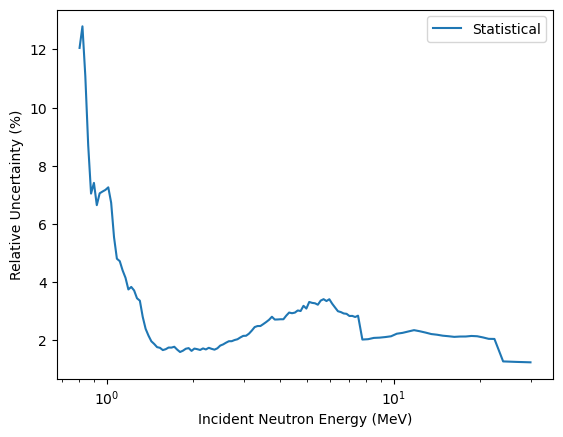

In [10]:
# data are from EXFOR. 
datafile = homedir+'DS6010Michalopoulou.txt'
alldata  = loadtxt(datafile,comments="#")
Einc = (alldata[:,0]+alldata[:,1])*0.5e-6
edgesE     = zeros(shape(alldata)[0]+1,dtype=float)
edgesE[0]  = alldata[0,0]*1.0e-6 # MeV
edgesE[1:] = alldata[:,1]*1.0e-6 # MeV
Data = alldata[:,2] # U-238(n,f)/U-235(n,f) cs.
Statunc = alldata[:,3]*100.0/alldata[:,2] # Statistical uncertainties are explicitly given in EXFOR.

normunc_U238 = 0.5
normunc_U235 = 0.5

amplitudecut_ffabsorption = 2.2*ones(shape(Einc),dtype=float) # They give an uncertainty for the "amplitude cut and 
# self-absorption correction"; this is a combined background (alphas and gammas) and 
# detector efficiency (FF losses) unc. defined in Table 2. The amplitude cut is fully 
# correlated as the correction is NOT energy dependent, but the FF absorption is energy dependent. 
# So, I list it as Gaussian correlated.
deadtime = 0.5*ones(shape(Einc),dtype=float) # they say negligibly small, <1% (for Th). I assume 0.5 which is large.
# I assume a strong correlation given the write-up of 0.8.
fluxoverlap_unc = 3.5*ones(shape(Einc),dtype=float)
beamfluence_unc = ones(shape(Einc),dtype=float)

plt.semilogx(Einc,Statunc)
plt.legend(['Statistical'])
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Relative Uncertainty (%)')

## Comments:
- This U-238(n,f)/U-235(n,f) is an absolute clean ratio measurement. The sample mass was determined with alpha counting.
- The data above 30 MeV are called out as biased by the authors because they needed to apply a lower voltage above 30 MeV for this sample which caused issues.
- The EXFOR file is very short for a recent measurement and is missing many uncertainty sources.
- Many more uncertainties are given in the paper than in the EXFOR entry. All pertinent uncertainties were documented except for impurity uncertainties which I assume with 0.1 % from the tempaltes.
- Losses of FF in the sample were claculated assuming isotropic angular distributions, which are non-negligible at the threshold and multiple-chance fission.
- They state that their deadtime unc. is negligibly small with < 1% which is large for a U-8 measurement. I assume 0.5% which is on the higher end. The correction is energy dependent. I assume a strong correlation given the write-up of 0.8.
- They give an uncertainty for the "amplitude cut and self-absorption correction"; this is a combined background (alphas and gammas) and detector efficiency (FF losses) unc. defined in Table 2. The amplitude cut is fully correlated as the correction is NOT energy dependent, but the FF absorption is energy dependent. So, I list it as Gaussian correlated.
- They have a beam-overlap issue as the beam is non-uniform, nor are their smaples. They assume 3.5% uncertainties that would also affect U-235 and U-238. The correction is energy dependent. I assume a Gaussian correlation.
- Concern: Forward boost was not mentioned in the corrections and that can matter for these high energies.
- Concern: FF were assumed to be emitted isotropically which is not true at the trehshold and multiple c.f.
- I assume a small impurity uncertainty from templates as the samples are described as of high purity.
- The energy resolution is retrieved from https://doi.org/10.1140/epja/s10050-025-01727-x .

In [13]:
features = { "Author": ["n_TOF collaboration", "V.Michalopoulou", "A.Stamatopoulos", "M.Diakaki", "et al."],
  "Year": "2023",
  "Facility": ["SYNCY", "2ZZZCER"],
  "Institute": ["2ZZZCER", "2GRCTUA", "2ZZZGEL", "2GRCIOA", "2FR PAR", "2ITYBAU", "2ITYUBO", "2BLGMOL",\
                "2SPNPCM","2ITYLNS","2ITYCAT","3POLLOU","2SPNVAL","2AUSATI","2FR SAC","2UK MAN",\
                "3CROZAG","2UK YRK","2ITYUPG","2SPNSAU","2SPNUPC","2SPNSEU","2ITYOAC","2UK EDG",\
                "2SWTPSI","2GERPTB","2GERFRK","2PRTLFE","2JPNJAE","2GERZFK","2GERKFK","3CZRCHU",\
                "2ITYPAD","2ITYBOL","2ITYTRI","3RUMBUC","2SPNGRU","2AUSVIE","2SWTBAS","2UK HFS",\
                "3INDTRM","3AULCBR"],
  "Isotope": "U-238/U-235",
  "Quantity": "cs",
  "reaction": "n,f",
  "MeasurementType": "absolute clean ratio",
  "ConcernEXFOR": "N/A",
  "Concern": ["Forward boost","FF angular distribution"],
  "Concern_text": ["Forward boost was not mentioned in the corrections and that can matter for these high energies.", \
                  "FF were assumed to be emitted isotropically which is not true at the trehshold and multiple c.f."],
  "BackgroundCorrected": "y",
  "AlphaBackground": "y",
  "GammaBackground": "y",
  "RandomCoincidenceBackground": "y",
  "ShadowBarBackground": "N/A",
  "WrapAroundBackground": "N/A",
  "MultipleScatteringSampleBackingCorrected": "y",
  "MultipleScatteringSurroundingCorrected": "y",
  "AttenuationSampleBackingCorrected": "y",
  "AttenuationSurroundingCorrected": "y",
  "FissionDetectionEfficiencyCorrected": "y",
  "SampleDecayCorrected": "y",
  "FissionFragmentAbsorptioninSampleCorrected": "y",
  "SignalPulsePileupCorrected": "y",
  "DeadtimeCorrected": "y",
  "AngularDistributionFissionFragmentsCorrected": "n",
  "ForwardBoostCorrected": "n",
  "ImpuritiesCorrected": "y",
  "CorrelatedData": ["23657.002", "23657.004"],
  "EXFORnumber": "23657.003",
  "Accepted": "y",
  "MissingCorrections": ["ForwardBoost","AngularDistributionFissionFragments"],
  "FissionDetector": {
    "Type": "IOCH",
    "ParticleDetected": "FF",
    "Efficiency": ["unknown"],
    "Efficiency_unit": "N/A",
    "EfficiencyMethod": "MC",
    "FFAbsorptionAngularDistributionMethod": "MC",
    "AngularAcceptaneofFF": "unknown",
    "Gas": {
      "Type": ["Ar", "CF4"],
      "Purity": ["unknown", "unknown"],
      "Pressure": "unknown",
      "Pressure_unit": "N/A"
    },
    "Size": {
      "geometry": "unknown"
    },
    "NoPhotomultipliers": "N/A",
    "Weight": "unknown",
    "StructuralMaterial": "unknown",
    "ReferenceDetector": "235U"#check
  },
  "NeutronDetector": {
    "Type": ["N/A"],
    "Number": ["N/A"],
    "ParticleDetected": "N/A",
    "Efficiency": ["unknown"],
    "ResponseDeterminationMethod": ["N/A"],
    "EfficiencyDeterminationMethod": ["N/A"],
    "Angle": ["N/A"],
    "trsl": {
      "Value": ["N/A"],
      "Unit": ["ns"],
      "Measure": "N/A"
    },
    "Gas": {
      "Type": ["N/A"],
      "Purity": ["N/A"],
      "Pressure": ["N/A"]
    },
    "Size": {
      "geometry": ["N/A"]
    },
    "NoPhotomultipliers": ["N/A"],
    "Photomultipliers": ["N/A"],
    "Weight": ["N/A"],
    "StructuralMaterial": ["N/A"],
    "ReferenceDetector": "N/A",
    "ReferenceReaction": "IOCH"
  },
  "Shielding": {
    "Material": "unknown",
    "Size": "unknown",
    "DistanceFromNeutronDetector": "N/A",
    "Purpose": "unknown"
  },
  "Sample": {
    "Number": 1,
    "Activity": 179.5,
    "Activity_unit": "Bq",
    "Reused": "unknown",
    "Form": "metal",
    "Mass": "179.5",
    "Mass_unit": "mg",
    "Diameter": 80.00,
    "Diameter_unit": "mm",
    "Thickness": "unknown",
    "Thickness_unit": "N/A",
    "Homogenity": "unknown",
    "Contaminants": {
      "238U": "high purity"
    },
    "BackingMaterial": "Al",
    "BackingDiameter": "unknown",
    "BackingDiameter_Unit": "mm",
    "BackingThickness": 0.025,
    "BackingThickness_Unit": "mm",
    "DecayDeterminationMethod": "calculated",
    "Configuration": "Stack",
    "Fabrication": "molecular plating",
    "ImpurityDetermination": ["thermal ionization mass spectrometry","calculated"],
    "NumberOfAtomsInSampleDeterminationTechnique": ["alpha counting"],\
  },
  "ShadowBar": {
    "Used": "n",
    "Material": "N/A",
    "Size": "N/A",
    "Size_unit": "N/A",
    "Material of structure holding it": "N/A"
  },
  "OutgoingEnergyDetermination": "TOF",
  "IndividualChannelWidthDetermination": "unknown",
  "AverageChannelWidthDetermination": "unknown",
  "BackgroundMethods": {
    "General": "unknown",
    "Wraparound": "unknown",
    "alpha": "PSD",
    "Gamma": "PSD",
    "RandomCoincidence": "N/A"
  },
  "MultipleScatteringMethods": {
    "InSample": ["MC"],
    "Surrounding": ["MC"]
  },
  "AttenuationMethods": {
    "InSample": ["MC"],
    "Surrounding": ["MC"]
  },
  "DeadtimeDeterminationMethod": "unknown",
  "EnergyDetermination": "TOF",
  "NeutronBeam": {
    "Facility": ["SYNCY", "SPALL", "2ZZZCER"],
    "PulseWidth": "unknown",
    "PulseWidthUnit": "ns",
    "NeutronProducingReaction": "p,Pb",
    "Target": "Pb",
    "EnergySpread": "unknown",
    "Monitor": "235U(n,f)",
    "Diameter": "unknown",
    "Diameter_unit": "cm",
    "TimeGateOpen": "N/A",
    "TimeGateOpen_unit": "N/A",
    "TOFLength": {
      "Value": 185.0,
      "Unit": "m",
      "Unc": "unknown",
      "Unc_Unit": "m"
    },
    "trsl": {
      "Value": "unknown",
      "Unit": "ns",
      "Measure": "N/A"
    },
    "t0Determination": ["gamma-flash","MC"]
  }
}

In [15]:
# ------------------------------------------------------------------
attenuation_multscatt_unc = 0.2*ones(shape(Einc)[0],dtype = float) # I assumed 20% of the correction.
# --------------------------------------------------------------------

# From Sanchez-Caballero measurement ---------------------------------
TOFlength = 185.0 # m
TOFlength_unc = 0.11 # m, difference between different samples
# --------------------------------------------------------------------

# I assume a small impurity uncertainty from templates as the samples are described as of high purity.
impurity_unc = 0.1*ones(shape(Einc)[0],dtype = float) 

# -------------------------------------------------------------------
Ersl = 0.042*ones(shape(Einc)[0],dtype = float)  # per https://doi.org/10.1140/epja/s10050-025-01727-x .
# This is FHWM energy resolution in energy percent.
for index in arange(0,shape(Einc)[0]):
    if Ersl[index] >= 0.1 and Einc[index] <= 1.0:
        Ersl[index] =  0.042+0.016*(Einc[index]-0.1)/(1.0-0.1)
    elif Ersl[index] > 1:
        Ersl[index] = 0.058

Testing covariance matrix of type Positive_fully:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Constant:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Constant:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

/Users/dneudecker/Documents/Codes/ARIADNE-github/
REFERENCE_LIBRARY_FILE: /Users/dneudecker/Documents/Codes/ARIADNE-github/Data/Re

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


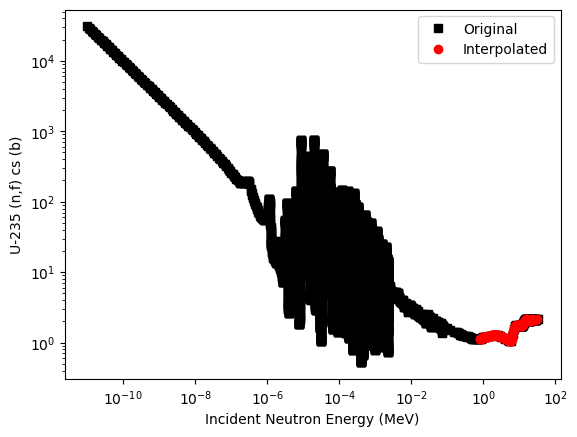

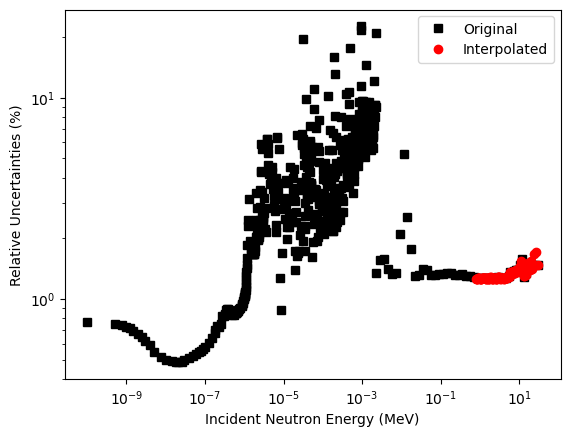

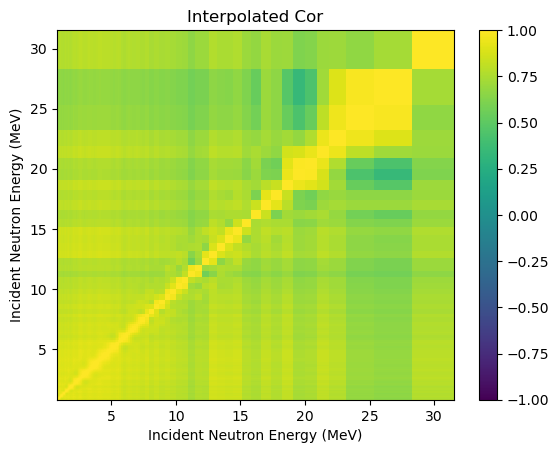

Testing interpolated covariance matrix of reference reaction:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing total covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

WIP: not yet included. No Xml file produced.

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/U-238/nfcs_DS6010Michalopoulou/DS6010.xml
{'isotope': 'U-238', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/U-238/nfcs_DS6010Michalopoulou/DS6010EUCLID.json
{'isotope': 'U-238', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}
{'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/U-238/nfcs_DS6010Michalopoulou/DS6010ratiodataEUCLID.json

Output file saved in file: /Users/dneudecker/Documents/Co

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


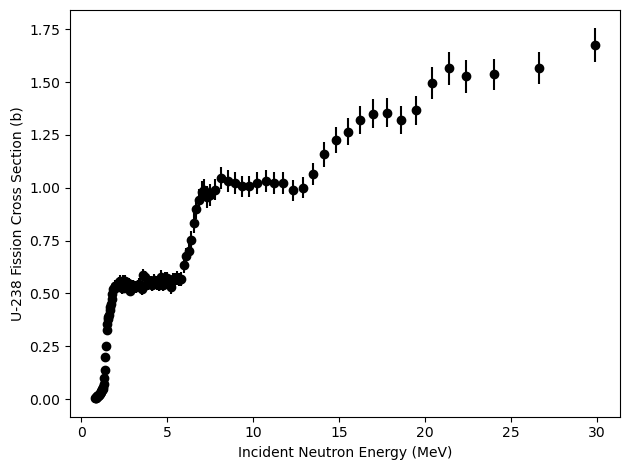

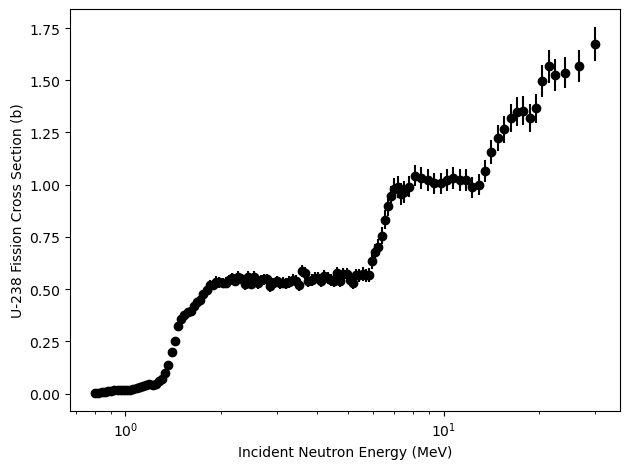

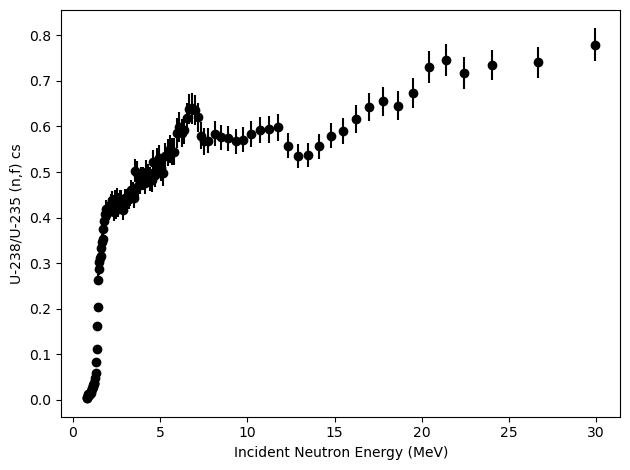

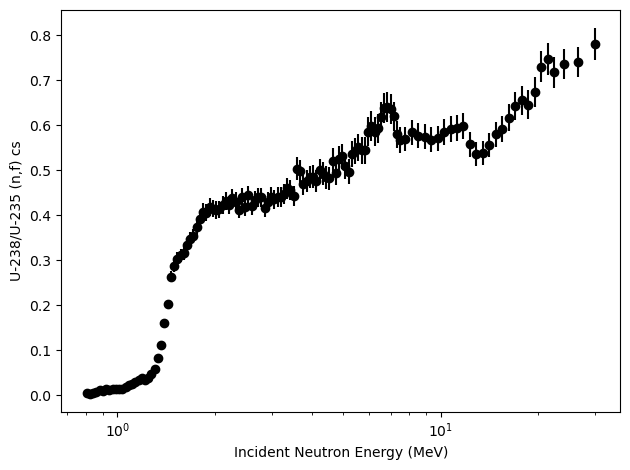

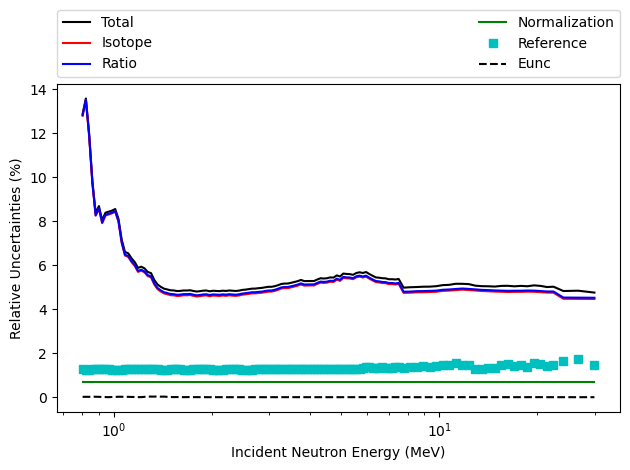

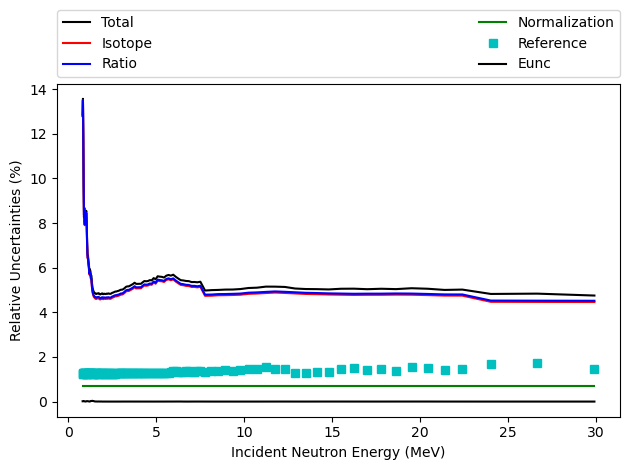

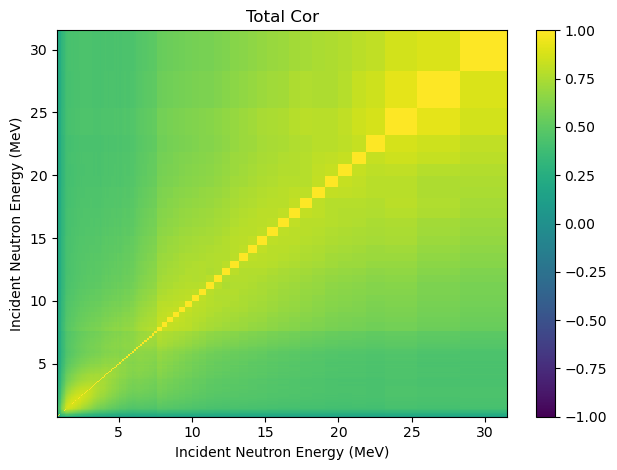

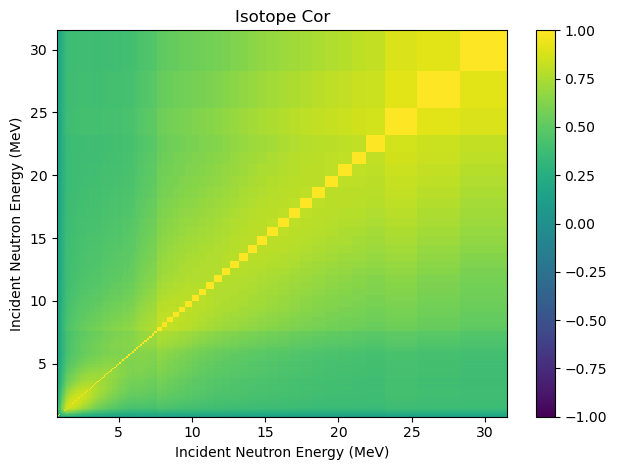

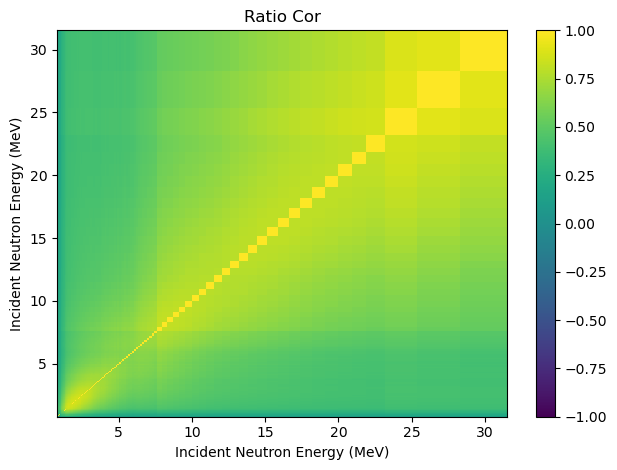

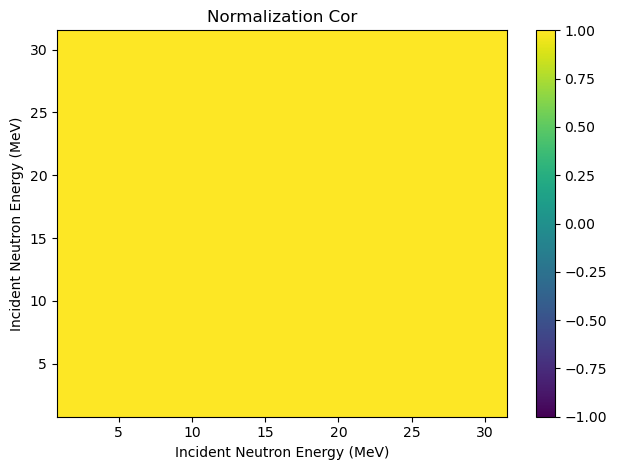

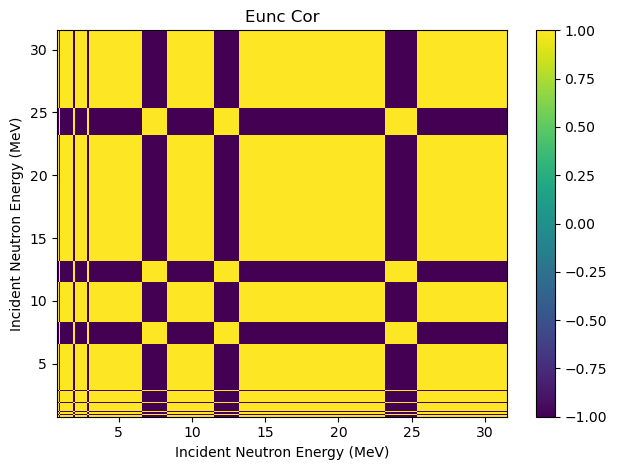

In [17]:
Documentation = """EXFOR No. = 23657003; Journal article = V.Michalopoulou et al., Physical Review, Part C, Nuclear Physics, Vol.108, p.014616 (2023).
- This U-238(n,f)/U-235(n,f) is an absolute clean ratio measurement. The sample mass was determined with alpha counting.
- The data above 30 MeV are called out as biased by the authors because they needed to apply a lower voltage above 30 MeV for this sample which caused issues.
- The EXFOR file is very short for a recent measurement and is missing many uncertainty sources.
- Many more uncertainties are given in the paper than in the EXFOR entry. All pertinent uncertainties were documented except for impurity uncertainties which I assume with 0.1 % from the tempaltes.
- Losses of FF in the sample were claculated assuming isotropic angular distributions, which are non-negligible at the threshold and multiple-chance fission.
- They state that their deadtime unc. is negligibly small with < 1% which is large for a U-8 measurement. I assume 0.5% which is on the higher end. The correction is energy dependent. I assume a strong correlation given the write-up of 0.8.
- They give an uncertainty for the "amplitude cut and self-absorption correction"; this is a combined background (alphas and gammas) and detector efficiency (FF losses) unc. defined in Table 2. The amplitude cut is fully correlated as the correction is NOT energy dependent, but the FF absorption is energy dependent. So, I list it as Gaussian correlated.
- They have a beam-overlap issue as the beam is non-uniform, nor are their smaples. They assume 3.5% uncertainties that would also affect U-235 and U-238. The correction is energy dependent. I assume a Gaussian correlation.
- Concern: Forward boost was not mentioned in the corrections and that can matter for these high energies, but hopefully small because ratio measurement.
- Concern: FF were assumed to be emitted isotropically which is not true at the trehshold and multiple c.f.
- I assume a small impurity uncertainty from templates as the samples are described as of high purity.
- All an said their method using the gamma flash is novel but not validated in paper; could lead to biases.
- The energy resolution is retrieved from https://doi.org/10.1140/epja/s10050-025-01727-x .
"""


general_info = {'name': 'DS6010', 'isotope': 'U-238', 'quantity': 'cs', 'reaction': 'n,f', \
                'output_file' : homedir+'DS6010.xml', \
                'output_folder' : homedir,\
                'documentation' : Documentation}

resolution = {
              'chw_edges': edgesE,
              'chw_edges_unit':'MeV',
              'tof_length':TOFlength,
              'tof_length_unit':'m',
              'energy_resolution': Ersl*Einc/100.0,
              'energy_resolution_unit': 'MeV'
              }

einc_unc = {'tof_length': {'value':  TOFlength ,'value_unit': 'm', 'unc': TOFlength_unc, 'unc_unit': 'cm'},\
            'en_err' : {'enerr_unc': array(Ersl*0.1/2.355),'enerr_unc_unit': '%','enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\
            'identifier_iso_deriv1' : 'ENDF/B-VIII.0','resolution':resolution}
# 'en_err' : {'enerr_unc': array(Eunc),'enerr_unc_unit': '%','enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\


reference = {'isotope': 'U-235','quantity': 'cs', 'reaction': 'n,f','identifier':'ENDF/B-VIII.0'}

normunc = sqrt(normunc_U238*normunc_U238+normunc_U235*normunc_U235)

norm_unc = {'value': normunc, 'unit':'%'}

unc_iso = {'einc_unc': einc_unc, 'normalization_unc':norm_unc, \
           'values':array([Statunc,amplitudecut_ffabsorption,deadtime,fluxoverlap_unc,beamfluence_unc,\
                           attenuation_multscatt_unc,impurity_unc]).transpose(),\
           'units':['%','%','%','%','%',\
                   ],\
           'type':['Diagonal','Gaussian','Constant','Gaussian','Gaussian',\
                  'Gaussian','Constant'],\
            'type_arg':{'einc':array(Einc),'damp_term':[1.0,1.0,0.8,1.0,1.0,\
                                                       1.0,0.8]}}

data = {'einc': array(Einc), 'einc_unit': 'MeV', 'values':array(Data), 'values_unit': "b" }

DS6010_nfcs = Cnf.nfcs_cleanratioabsolute(general_info,data,unc_iso,reference,features)

Text(0, 0.5, 'Relative Uncertainty (%)')

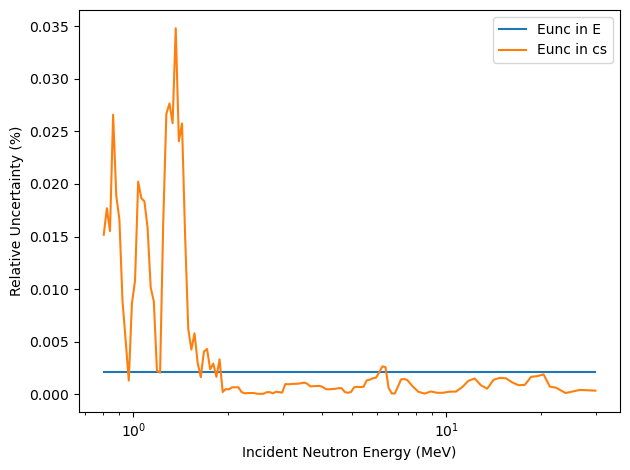

In [21]:
# get energy uncertainties in energy
dim = shape(Einc)[0]
cscov = DS6010_nfcs.cov_eunc
Euncov = zeros([dim,dim],dtype=float)

deriv_nucdata = [ 3.93733089e-02,4.02418203e-02,4.50688618e-02,1.24887933e-01\
,1.22769040e-01,8.61721209e-02,5.94078424e-02,-3.29031043e-02\
,-8.69189805e-03,-5.74318686e-02,7.00672831e-02,1.32239679e-01\
,1.55902962e-01,1.88467237e-01,1.74790759e-01,1.21600102e-01\
,1.18779420e-01,-3.33366310e-02,-2.66871461e-02,2.30541033e-01\
,4.68144767e-01,5.89050253e-01,7.45740783e-01,1.33201369e+00\
,1.29591857e+00,1.70731266e+00,1.26423452e+00,5.56921505e-01\
,3.92431394e-01,5.36796440e-01,2.74265459e-01,1.54079116e-01\
,3.91519991e-01,4.14104503e-01,2.36290792e-01,2.95751640e-01\
,1.70821567e-01,3.33630838e-01,-2.15043736e-02,-4.86481000e-02\
,4.37494505e-02,6.16917496e-02,6.19216865e-02,6.21583096e-02\
,1.96678148e-02,8.01722399e-03,9.58885937e-03,9.63750906e-03\
,9.36108879e-03,4.04043917e-03,3.21202063e-03,3.22869182e-03\
,1.40820517e-02,1.54837757e-02,6.10194177e-03,-1.63371468e-02\
,-1.40613272e-02,1.04571703e-02,6.46748859e-02,6.20970064e-02\
,6.27287311e-02,6.33851919e-02,6.40676632e-02,6.47775411e-02\
,6.55162143e-02,6.52041664e-02,4.74963412e-02,4.45979123e-02\
,4.50644636e-02,4.55495060e-02,3.83912944e-02,2.60386117e-02\
,2.62118975e-02,2.63910145e-02,2.65762051e-02,2.88502461e-02\
,3.02940086e-02,1.03287920e-02,7.02196830e-03,1.09404341e-02\
,3.12603703e-02,3.16279364e-02,3.21799609e-02,3.30130901e-02\
,6.09164314e-02,6.18769293e-02,6.65476094e-02,7.23057159e-02\
,9.55218594e-02,1.16210995e-01,1.11675310e-01,2.67329628e-02\
,-3.39636049e-03,-3.10252941e-03,-3.12700763e-02,-5.70983810e-02\
,-5.35010111e-02,-4.74064621e-02,-2.75684100e-02,-7.90956789e-03\
,2.03249203e-03,8.05979706e-03,3.91865796e-03,3.96437978e-03\
,6.52280508e-03,6.53670755e-03,1.66074900e-02,-3.03814913e-02\
,-3.16028754e-02,-1.64807631e-02,9.90833508e-03,2.51864716e-02\
,2.84971051e-02,2.69337094e-02,1.99303776e-02,1.52683245e-02\
,1.52401850e-02,2.68302597e-02,2.77941143e-02,3.15154704e-02\
,1.18175450e-02,9.28852496e-03,-1.65166658e-03,5.34834486e-03\
,4.20884394e-03
]

for index1 in arange(0,dim):
    for index2 in arange(0,dim):
        Euncov[index1,index2]=cscov[index1,index2]*\
        Data[index1]*Data[index2]/\
        (Einc[index1]*Einc[index2]*deriv_nucdata[index1]*deriv_nucdata[index2])
        
# the energy uncertainty is so small that it is negligible.

Euncrelunc = sqrt(diag(Euncov))
plt.semilogx(Einc,Euncrelunc)
plt.semilogx(Einc,sqrt(diag(cscov)))
plt.legend(['Eunc in E','Eunc in cs'])
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Relative Uncertainty (%)')

In [23]:
GMAnewnumber='6010'
year = features["Year"]
authors = 'Michalopoulou (n_TOF)'
journal = 'J,PRC,108(2023)'
        

normalizationunc = [normunc_U238,normunc_U235,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]


uncertainty_descriptor = ['UNCERTAINTIES','1 Normal. unc.: U8 normalization, U5 normalization',\
                          '1 Energy unc. is negligibly small',\
                          '2 Energy resl from https://doi.org/10.1140/epja/s10050-025-01727-x negligibly small',\
                          '3 Statistical Unc.','4 amplitude cut and self-absorption correction uncertainty (backgrd. and det. eff.)',\
                          '5 Deadtime unc.',\
                          '6 Unc. due to beam intensity and spatial dependence between sample and beam',\
                          '7 Neutron beam fluence',\
                          '8 Multiple scatt. and attenuation unc.',\
                         '9 impurity unc. from templates',\
                         'Angular distribution assumed isotropic which could bias data near thresholds.',\
                         'Forward boost correction not mentioned; assumed to be small (ratio measurement).',\
                         'Their method using the gamma flash not validated in paper; could lead to biases.',\
                         'Systematic unc. from 230Th measurement adopted (all foils measured at once).']
abc_components = ones([11,3],dtype=float)*0.5
abc_components[0,:] = [0.99, 0.01,0.5]
abc_components[1:3,:] = zeros([2,3],dtype=float)
abc_components[3,:] = [0.1, 0.9,0.01]
abc_components[4:9,:] = [0.99,0.01,0.5]
abc_components[5,:] = [0.0, 1.0,0.01]

uncertainties = zeros([dim,12],dtype=float)
uncertainties[:,:7] = array([Statunc,amplitudecut_ffabsorption,deadtime,fluxoverlap_unc,beamfluence_unc,\
                           attenuation_multscatt_unc,impurity_unc]).transpose()

controlnumber = [0,0,9,1,1,1,1,1,1,0,0]

data = {'einc': Einc, 'einc_unit': 'MeV', 'values':Data, 'values_unit': "none" }
Enrsl = Ersl
Eunc = zeros(dim,dtype=float)
abs_shape = 'absolute'

In [25]:
import WriteGMAOutput as WGMA
print(WGMA.WriteGMAOutput(GMAnewnumber,year,authors,journal,general_info,uncertainty_descriptor,data,reference,\
                     abs_shape,abc_components,Eunc,Enrsl,uncertainties,controlnumber,normalizationunc))

5
5
5
5
5
5
5
5
5
5
/Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/U-238/nfcs_DS6010Michalopoulou/DS6010.CRD
